In [2]:
from core.analysis_config import AnalysisConfig
from core.reference import Reference
from core.observable import ObsType
from utils.analyzer import Analyzer
from utils.results_manager import ResultsManager
from utils.workdirectory import WorkDirectory
from utils.plotting import PlotLimits, CMSPlotStyle
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import mplhep
plt.style.use(mplhep.style.CMS)

Welcome to JupyROOT 6.30/02


In [3]:
%config InlineBackend.figure_format = 'retina'

In [8]:
def plot_brazilian(df: pd.DataFrame, outfile, plot_style=None, label_column='label'):
    """
    Create a CMS-style horizontal bar plot showing confidence limits
    
    Parameters:
    - df: DataFrame with columns ['label', 'median', 'down1', 'up1', 'down2', 'up2']
    - outfile: Output filename for the plot
    - plot_style: CMSPlotStyle object (optional, uses default if not provided)
    - label_column: Name of column containing labels (default 'label')
    """
    # Use default style if none provided
    if plot_style is None:
        plot_style = CMSPlotStyle()
    
    # Setup figure using the style class
    fig, ax = plot_style.setup_figure()
    
    if df.empty:
        print("No data to plot!")
        return
    
    labels = df[label_column].tolist()
    N = len(labels)
    
    # CONTROL BAR THICKNESS AND SPACING
    bar_height = 0.5  # thinner bars
    bar_spacing = 0   # zero spacing

    for i, (_, row) in enumerate(df.iterrows()):
        label = row[label_column]
        median = row["mu"]
        # Calculate confidence intervals from your data structure
        low1 = median - row["sigma1_min"]
        high1 = row["sigma1_max"] - median
        low2 = median - row["sigma2_min"]
        high2 = row["sigma2_max"] - median

        y_center = i * (bar_height + bar_spacing)

        # ±2σ band
        ax.barh(y_center, low2 + high2, left=median - low2, height=bar_height, 
                color="gold", zorder=1, edgecolor='none')
        # ±1σ band
        ax.barh(y_center, low1 + high1, left=median - low1, height=bar_height, 
                color="forestgreen", zorder=2, edgecolor='none')
        # Median line
        ax.vlines(median, y_center - bar_height / 2, y_center + bar_height / 2, 
                  color="black", linestyle="--", linewidth=1.2, zorder=3)

        # Text labels
        text_label_x_pos = -0.25
        ax.text(text_label_x_pos, y_center + 0.07, f"{label}", ha="left", fontsize=plot_style.tick_fs, 
                weight='bold', transform=ax.get_yaxis_transform())
        ax.text(text_label_x_pos, y_center - 0.07, f"Expected {median:.2f}", ha="left", 
                fontsize=plot_style.tick_fs, transform=ax.get_yaxis_transform())

    # Vertical theory line
    y_top_center = (N - 1) * (bar_height + bar_spacing)
    y_top_edge = y_top_center + bar_height / 2
    ax.vlines(x=1.0, ymin=-bar_height / 2, ymax=y_top_edge, color="red", 
              linestyle="-", linewidth=1.5, zorder=4)
    
    # Axis styling
    ax.set_xlim(left=0)
    
    # Set axis labels
    xlabel = plot_style.xlabel if plot_style.xlabel else r"Upper 95% CLs limit on $\sigma(\mathrm{pp} \rightarrow \mathrm{HH}) / \sigma_\mathrm{SM}$"
    ax.set_xlabel(xlabel, fontsize=plot_style.label_fs)
    
    # Configure x-axis ticks
    ax.tick_params(axis="x", labelsize=plot_style.tick_fs, zorder=5)
    # Force the ticks and spines to be drawn on top
    ax.set_axisbelow(False)

    # Add CMS text using the style class
    plot_style.add_cms_text(ax)

    # ============================================
    # Legend =====================================
    # ============================================
    theory_legend = [plt.Line2D([0], [0], color="red", linestyle="-", label="Theory prediction")]

    from matplotlib.patches import Rectangle
    from matplotlib.legend_handler import HandlerBase

    # Custom handler to draw a patch with a dashed line through the center
    class PatchWithLineHandler(HandlerBase):
        def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
            patch_color = orig_handle[0]
            line_style = orig_handle[1]
            # Full-size patch
            patch = Rectangle([xdescent, ydescent], width, height, facecolor=patch_color, 
                            edgecolor="none", transform=trans, zorder=1)
            # Dashed line through center
            line = plt.Line2D([xdescent, xdescent + width], [ydescent + height / 2] * 2, 
                            linestyle=line_style, color="black", linewidth=1.5, transform=trans, zorder=2)
            return [patch, line]

    # Define legend handles as (color, linestyle)
    green_legend = ("forestgreen", "--")
    yellow_legend = ("gold", "--")

    # Legend items
    other_legend = [
        green_legend,
        yellow_legend,
        plt.Line2D([0], [0], color="black", linestyle="--", label="Median expected")
    ]

    # Create legends with consistent font size from style class
    legend_fontsize = plot_style.tick_fs  # Use tick font size for legends
    leg_y_pos = 0.92
    fig.legend(handles=theory_legend, loc="upper right", bbox_to_anchor=(0.66, leg_y_pos), 
               fontsize=legend_fontsize, frameon=False)
    fig.legend(handles=other_legend, labels=[r"$\pm 1\sigma$ expected", r"$\pm 2\sigma$ expected", "Median expected"],
               loc="upper right", bbox_to_anchor=(0.95, leg_y_pos), fontsize=legend_fontsize, frameon=False, 
               handler_map={tuple: PatchWithLineHandler()})

    # Set y-axis limits precisely to avoid spacing
    total_height = N * (bar_height + bar_spacing)
    top_margin = 0.6
    yticks = []
    for i in range(N):
        y_center = i * (bar_height + bar_spacing)
        yticks.extend([y_center - bar_height / 2, y_center + bar_height / 2])
    ax.set_yticks(yticks)
    
    # Remove minor ticks and customize major ticks
    ax.tick_params(axis="y", which="minor", left=False, right=False)
    ax.tick_params(axis="y", which="major", length=12, width=2, labelsize=0, left=True, right=True)
    
    ax.set_ylim(-bar_height / 2, total_height - bar_spacing - bar_height / 2 + top_margin)
    ax.grid(False, axis='y')

    plt.tight_layout()
    plt.savefig(outfile, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"CMS-style limits plot saved to {outfile}")
    plt.show()

In [9]:
df = pd.DataFrame({
    "obs_name": ["2022", "2023", "Combined"],
    "mu": [24.6875, 31.9062, 19.3125],
    "sigma1_min": [17.6200, 22.8486, 13.8300],
    "sigma1_max": [34.8233, 44.7514, 27.2415],
    "sigma2_min": [13.1635, 17.1371, 10.3729],
    "sigma2_max": [47.2435, 60.4735, 36.4656]
})

df = df.sort_values('mu', ascending=True).reset_index(drop=True)

CMS-style limits plot saved to final_model/UL_brazilian.pdf


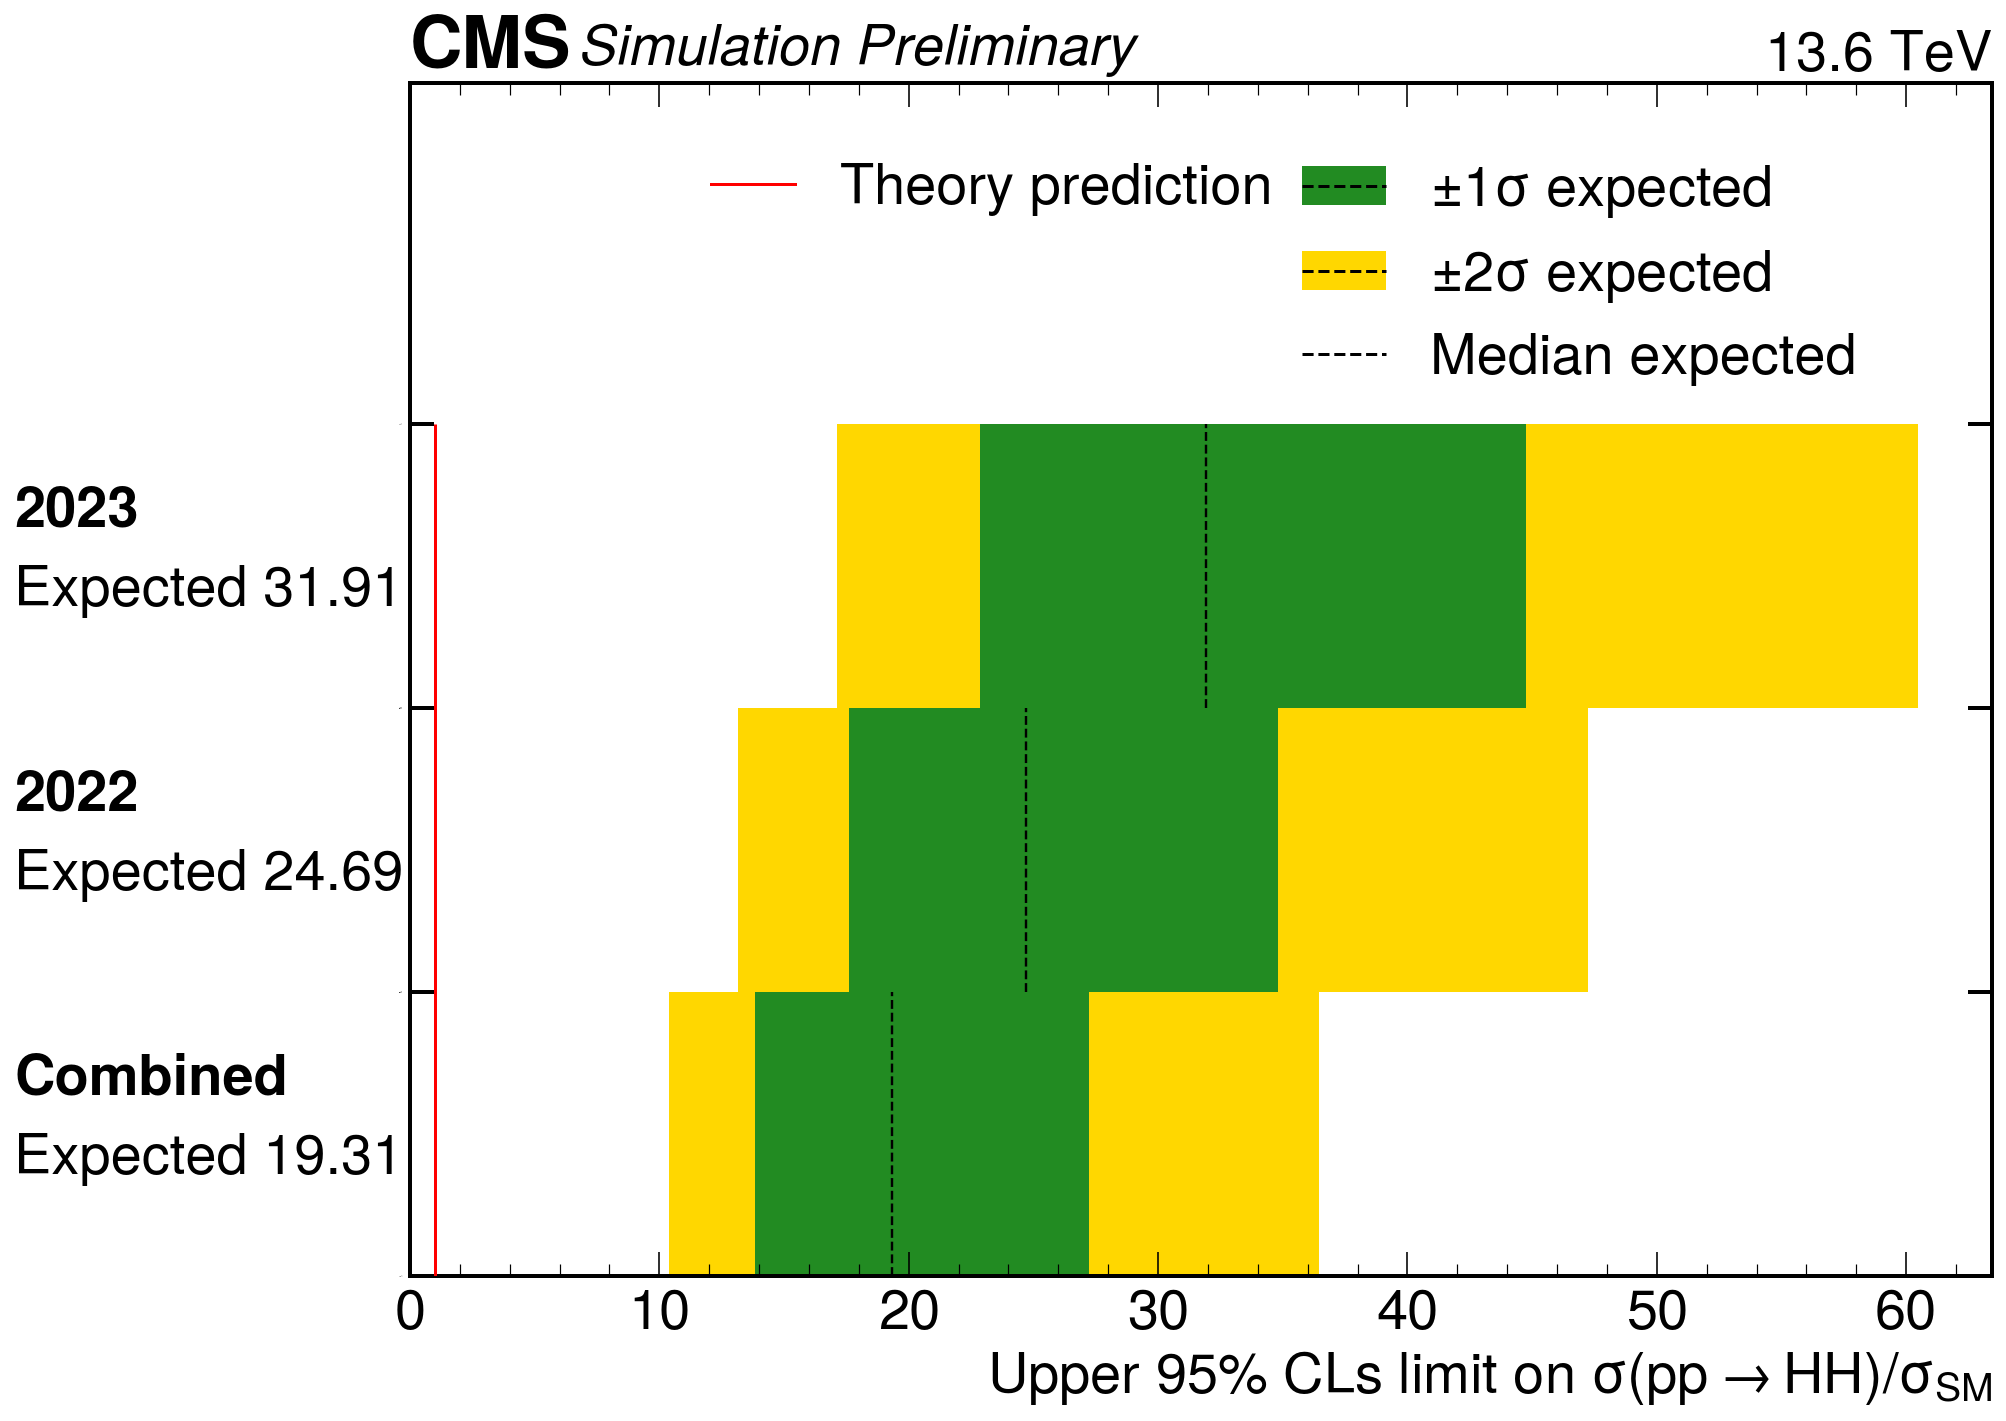

In [10]:
fs = 28
plot_style = CMSPlotStyle(
    figsize=(14,10), 
    label_fs=fs,
    tick_fs=fs,
    cms_fs=fs
)
plot_brazilian(df, 
                outfile=Path('final_model') / 'UL_brazilian.pdf',
                plot_style = plot_style,
                label_column='obs_name')